# VCE copula read-off: the marginal-matching decomposition

VCE reads MI off a copula MoG fit on flow latents. Sweeping the number of kept mixture
components `V` (weight-sorted top-V) exposes *why* the read is biased.

**Estimator bias identity.** With model marginals $q_X,q_Y$ and joint $q_J$, expectation over real data $p$:
$$\widehat{\mathrm{MI}}-\mathrm{MI}=\underbrace{\mathrm{KL}(p_X\|q_X)+\mathrm{KL}(p_Y\|q_Y)}_{\text{marginal misfit}\ \ge 0}-\underbrace{\mathrm{KL}(p_J\|q_J)}_{\text{joint misfit}\ \ge 0}.$$
If the marginals match exactly, $\widehat{\mathrm{MI}}=\mathrm{MI}-\mathrm{KL}(p_J\|q_J)\le\mathrm{MI}$ is a lower bound that tightens as the
joint fit improves — so held-out NLL selection is justified. If they don't, the $+\,\mathrm{KL}_X+\mathrm{KL}_Y$ term
biases the read and NLL selection stops tracking MI.

In [1]:
%matplotlib inline
import math
import numpy as np
import torch
import matplotlib.pyplot as plt

import optimizer
from nde.MoG import MoG
from test_vce_test_time_search import get_latents, DATASETS, N_RESTARTS  # cached flow latents

DEVICE = 'cuda:0' if torch.cuda.is_available() else 'cpu'
K, LOG2PI = 16, math.log(2 * math.pi)
IDEAL = 0.5 * 32 * (1 + LOG2PI)   # side-marginal NLL of exact N(0, I_32) = 45.41
print('device', DEVICE, '| K', K, '| exact-N(0,I) side margNLL =', round(IDEAL, 2))

device cuda:0 | K 16 | exact-N(0,I) side margNLL = 45.41


## Sweep V=1..K on the canonical read-out member
For each `V` we record: joint NLL on train / val / full; the mixture MI read; the $\phi$ read (exact
per-dim $N(0,1)$ marginals); and the two side-marginal NLLs. Reuses cached latents — no flow retrain.

In [2]:
def topv_mask(mog, m, V):
    order = torch.argsort(mog.logits[m], descending=True)
    mask = torch.zeros(mog.M, mog.K, dtype=torch.bool, device=mog.logits.device)
    mask[m, order[:V]] = True
    return mask

def logphi(z):
    return -0.5 * (z ** 2).sum(1) - 0.5 * z.size(1) * LOG2PI

def sweep(name):
    v, w, gt, d = get_latents(name)
    torch.manual_seed(0)
    mog = MoG(d=d, K=K, M=N_RESTARTS, copula=True).to(v.device)
    mog.learn(v, w)
    m = mog.best_idx                                  # canonical full-K read member
    vv, ww = mog.forward(v, w)                        # rank-space halves
    z = torch.cat([vv, ww], dim=1)
    z_tr, _, z_va, _ = optimizer.NNOptimizer.divide_train_val(z, torch.ones_like(z))
    dx, dy = list(range(d)), list(range(d, 2 * d))
    r = {k: [] for k in ('V', 'ntr', 'nva', 'nfu', 'mi_mix', 'mi_phi', 'mnx', 'mny')}
    for V in range(1, K + 1):
        mask = topv_mask(mog, m, V)
        l_xy = mog._member_logprobs(z, active=mask)[m]
        l_x = mog._marginal_logprob(vv, dx, m, active=mask)
        l_y = mog._marginal_logprob(ww, dy, m, active=mask)
        r['V'].append(V)
        r['ntr'].append(float(-mog._member_logprobs(z_tr, active=mask)[m].mean()))
        r['nva'].append(float(-mog._member_logprobs(z_va, active=mask)[m].mean()))
        r['nfu'].append(float(-l_xy.mean()))
        r['mi_mix'].append(float((l_xy - l_x - l_y).mean()))
        r['mi_phi'].append(float((l_xy - logphi(vv) - logphi(ww)).mean()))
        r['mnx'].append(float(-l_x.mean())); r['mny'].append(float(-l_y.mean()))
    r['name'], r['gt'], r['m'] = name, gt, m
    r['v_argmin'] = int(np.argmin(r['nva'])) + 1
    return r

RES = [sweep(n) for n in DATASETS]
print('swept:', [r['name'] for r in RES])

[phase1] student_t_df1: loaded cached latents (10000, 32) (GT=12.456)
finished: t= 0 loss= 401.31878662109375 loss val= 399.3816223144531 best val loss= 399.3816223144531 best t= 0
finished: t= 101 loss= 66.75749206542969 loss val= 69.70677185058594 best val loss= 69.69940185546875 best t= 88
finished: t= 202 loss= 66.75822448730469 loss val= 69.69943237304688 best val loss= 69.69107055664062 best t= 146
finished: t= 303 loss= 66.88775634765625 loss val= 69.70451354980469 best val loss= 69.688232421875 best t= 209
finished: t= 404 loss= 66.64485168457031 loss val= 69.71525573730469 best val loss= 69.688232421875 best t= 209


[phase1] mog_K5: loaded cached latents (10000, 32) (GT=6.906)
finished: t= 0 loss= 393.78778076171875 loss val= 413.8786926269531 best val loss= 413.8786926269531 best t= 0
finished: t= 101 loss= 82.34304809570312 loss val= 87.00823211669922 best val loss= 87.00823211669922 best t= 101
finished: t= 202 loss= 81.83953857421875 loss val= 86.86351776123047 best val l

## Figure 1 — NLL(V) vs MI(V)
`NLL train` falls monotonically; `NLL val` bottoms early then goes **flat** (basin rise ≪ 1 SE);
`MI` climbs monotonically and never turns over. The dotted line marks the val-NLL argmin (= BoN's pick).

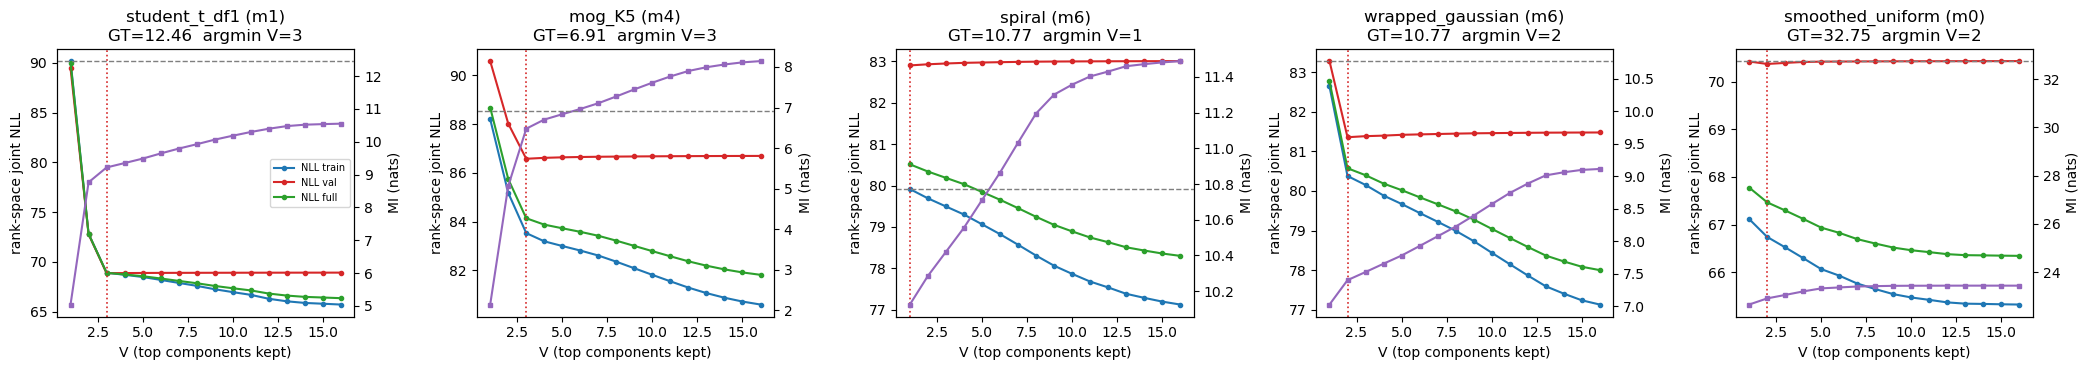

In [3]:
fig, axes = plt.subplots(1, len(RES), figsize=(4.2 * len(RES), 3.8))
for ax, r in zip(axes, RES):
    V = r['V']
    ax.plot(V, r['ntr'], '-o', ms=3, color='#1f77b4', label='NLL train')
    ax.plot(V, r['nva'], '-o', ms=3, color='#d62728', label='NLL val')
    ax.plot(V, r['nfu'], '-o', ms=3, color='#2ca02c', label='NLL full')
    ax.axvline(r['v_argmin'], ls=':', color='#d62728', lw=1.2)
    ax.set_xlabel('V (top components kept)'); ax.set_ylabel('rank-space joint NLL')
    ax2 = ax.twinx()
    ax2.plot(V, r['mi_mix'], '-s', ms=3, color='#9467bd', label='MI')
    ax2.axhline(r['gt'], ls='--', color='#7f7f7f', lw=1); ax2.set_ylabel('MI (nats)')
    ax.set_title(f"{r['name']} (m{r['m']})\nGT={r['gt']:.2f}  argmin V={r['v_argmin']}")
axes[0].legend(loc='center right', fontsize=7)
fig.tight_layout(); plt.show()

## Figure 2 — marginal-matching decomposition
**Top:** mixture read `MI_mix` vs exact-marginal read `MI_φ` vs GT; the shaded band is the marginal-misfit
bias. **Bottom:** the mixture side-marginal NLLs vs the exact $N(0,I)$=45.41 line — drift below the line
*is* that bias. GT is **bracketed** between the two reads wherever the marginals drift.

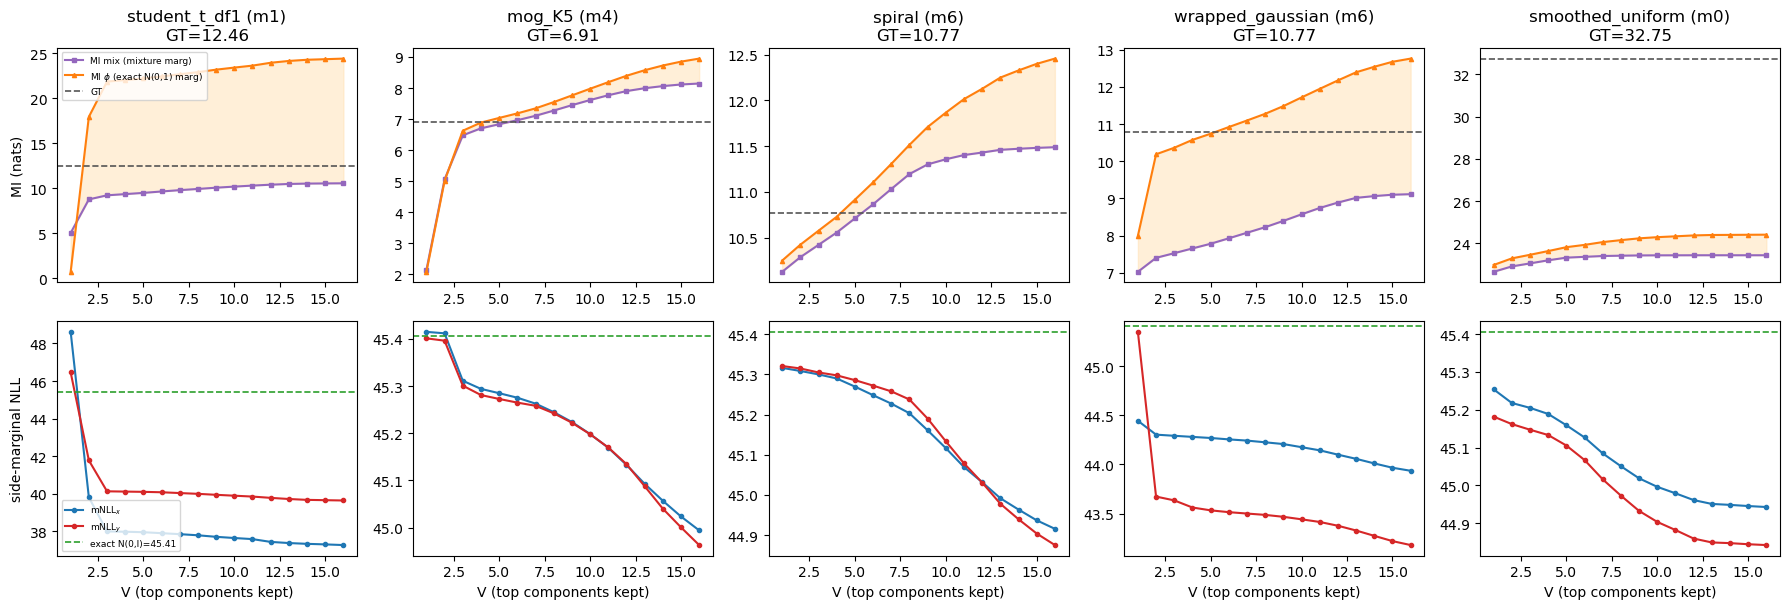

In [4]:
fig, axes = plt.subplots(2, len(RES), figsize=(3.6 * len(RES), 6.2))
for j, r in enumerate(RES):
    V = r['V']
    a = axes[0, j]
    a.plot(V, r['mi_mix'], '-s', ms=3, color='#9467bd', label='MI mix (mixture marg)')
    a.plot(V, r['mi_phi'], '-^', ms=3, color='#ff7f0e', label='MI $\\phi$ (exact N(0,1) marg)')
    a.axhline(r['gt'], ls='--', color='#555', lw=1.2, label='GT')
    a.fill_between(V, r['mi_mix'], r['mi_phi'], color='#ffe1b3', alpha=0.5, zorder=0)
    a.set_title(f"{r['name']} (m{r['m']})\nGT={r['gt']:.2f}")
    a.set_ylabel('MI (nats)' if j == 0 else '')
    if j == 0: a.legend(fontsize=6.5, loc='upper left')
    b = axes[1, j]
    b.plot(V, r['mnx'], '-o', ms=3, color='#1f77b4', label='mNLL$_x$')
    b.plot(V, r['mny'], '-o', ms=3, color='#d62728', label='mNLL$_y$')
    b.axhline(IDEAL, ls='--', color='#2ca02c', lw=1.2, label='exact N(0,I)=45.41')
    b.set_xlabel('V (top components kept)')
    b.set_ylabel('side-marginal NLL' if j == 0 else '')
    if j == 0: b.legend(fontsize=6.5, loc='lower left')
fig.tight_layout(); plt.show()

## Takeaways
- **Matched-marginal regime (mog / spiral / uniform):** mixture marginals stay ≈ 45.41 ⇒ `MI_mix` ≈ `MI_φ`.
  The clean regime: the over-read is joint in-sample overfit, which held-out (BoN) selection prunes toward GT.
- **Mismatched-marginal regime (wrapped / student-t):** the mixture absorbs dependence into the marginals
  (mNLL crashes to 43 / 37) ⇒ `MI_mix` under-reads, `MI_φ` over-reads, **GT bracketed between**. Not fixable by
  component selection — needs a marginal-aware read-off or a better marginal flow (e.g. NAF).
- So held-out NLL selection is justified **exactly when the marginals are matched**, per the bias identity.